# DGP sanity plots

Sample each DGP and visualize Y vs X1 with treatment coloring, plus true CATE/ATE lines.
CATE is plotted on a secondary y-axis with other covariates fixed at 0.


In [1]:
import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso

from src import _DGP_REGISTRY, fit_nuisance_models, compute_phi_aipw, compute_phi_and_nuisances, build_features

SEED = 123
N = 30000
N_GRID = 200
PHI_N_SPLITS = 5
DEVICE = 'cpu'
DR_ALPHA = 0.05


In [3]:
def dgp_sort_key(name: str) -> int:
    try:
        return int(name.split('_')[1])
    except Exception:
        return 0

def make_grid_x(x: np.ndarray, n_grid: int) -> np.ndarray:
    d = x.shape[1]
    x1 = x[:, 0]
    lo, hi = np.percentile(x1, [1, 99])
    grid = np.linspace(lo, hi, n_grid)
    if d == 1:
        return grid.reshape(-1, 1)
    xg = np.tile(x.mean(axis=0), (n_grid, 1))
    xg[:, 0] = grid
    return xg


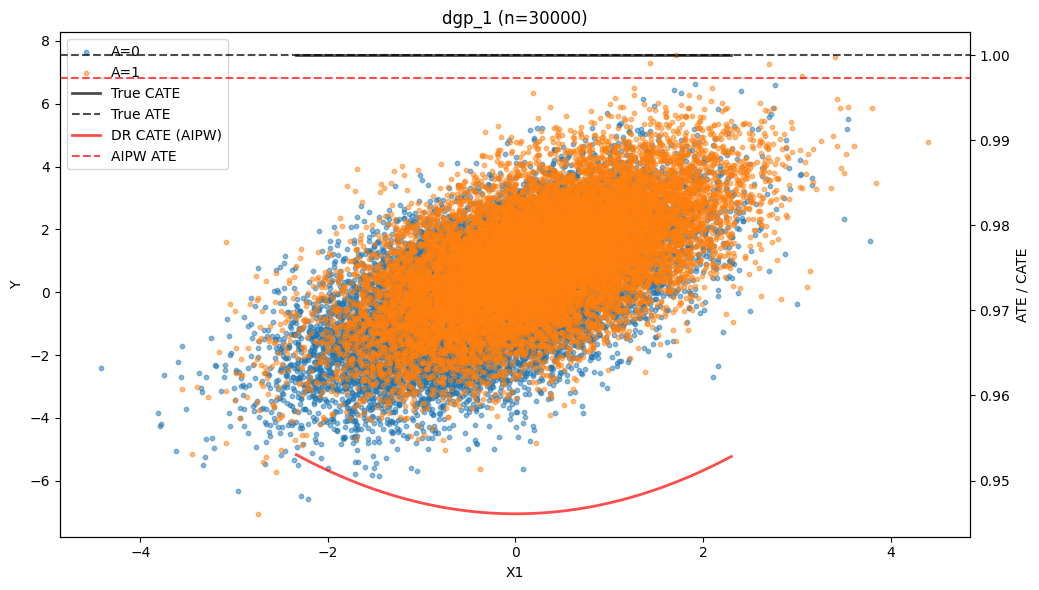

dgp_1 CATE MSE: 0.002668 | ATE MSE: 0.000007


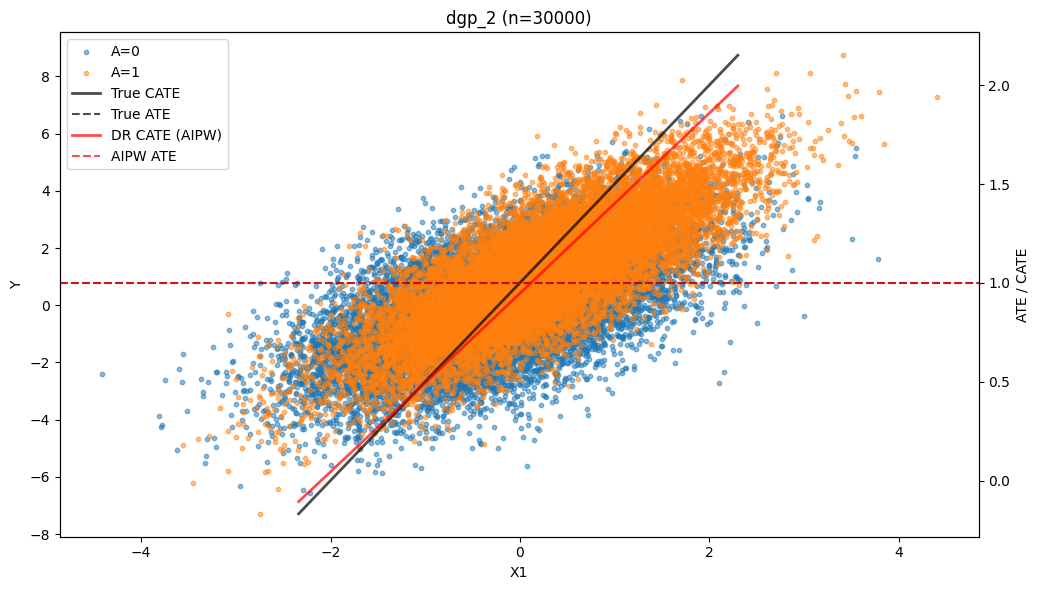

dgp_2 CATE MSE: 0.006509 | ATE MSE: 0.000000


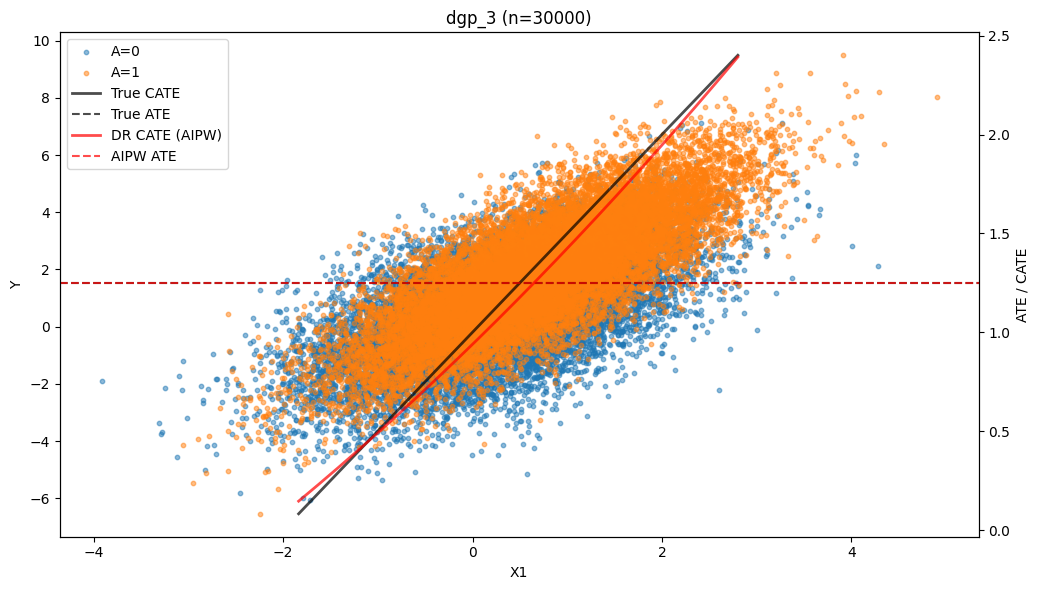

dgp_3 CATE MSE: 0.002882 | ATE MSE: 0.000001


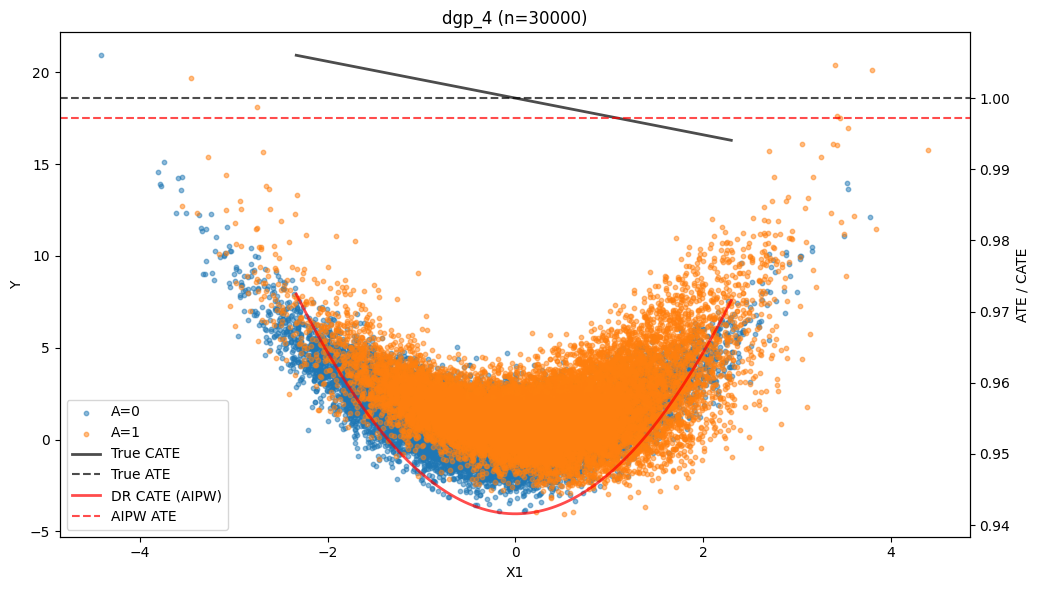

dgp_4 CATE MSE: 0.002420 | ATE MSE: 0.000008


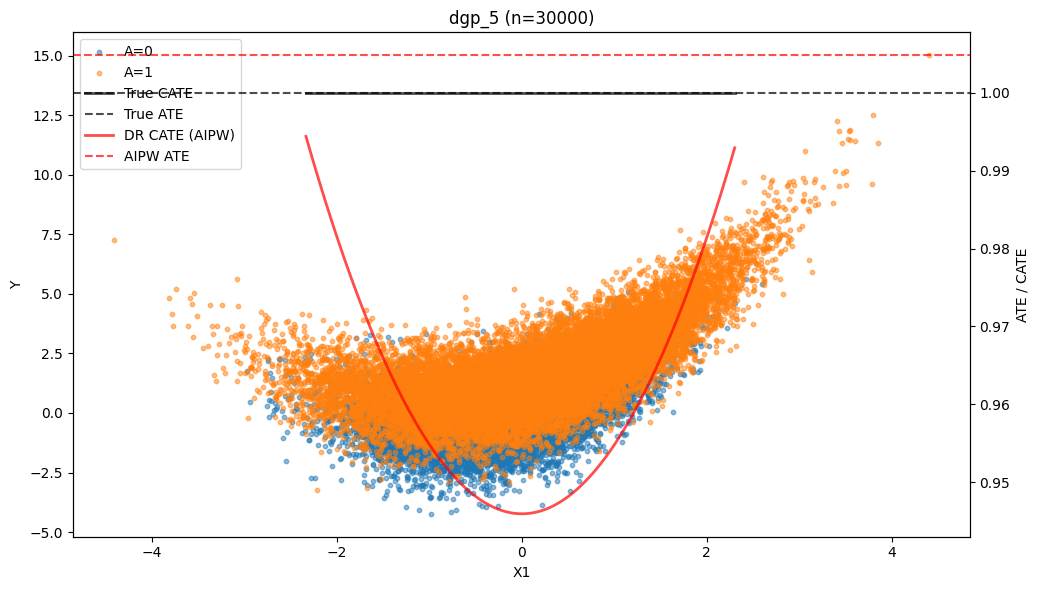

dgp_5 CATE MSE: 0.001650 | ATE MSE: 0.000023


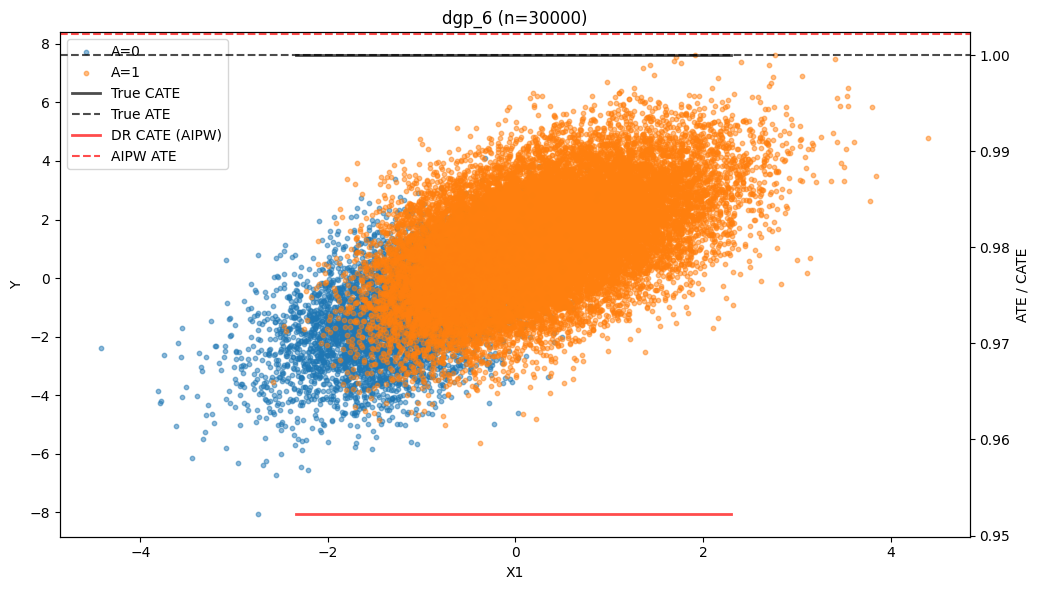

dgp_6 CATE MSE: 0.002279 | ATE MSE: 0.000005


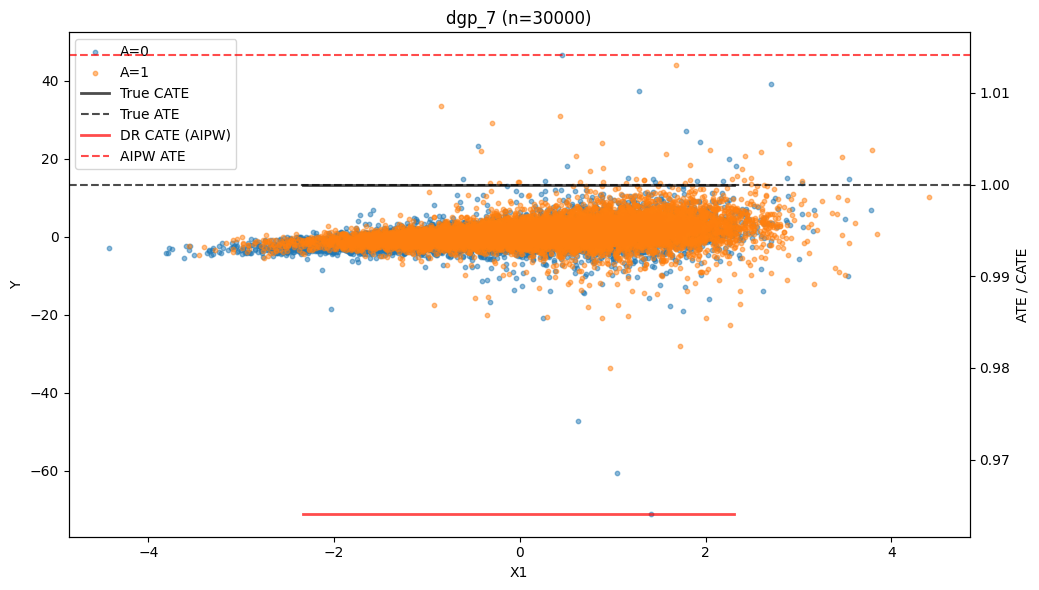

dgp_7 CATE MSE: 0.001289 | ATE MSE: 0.000199


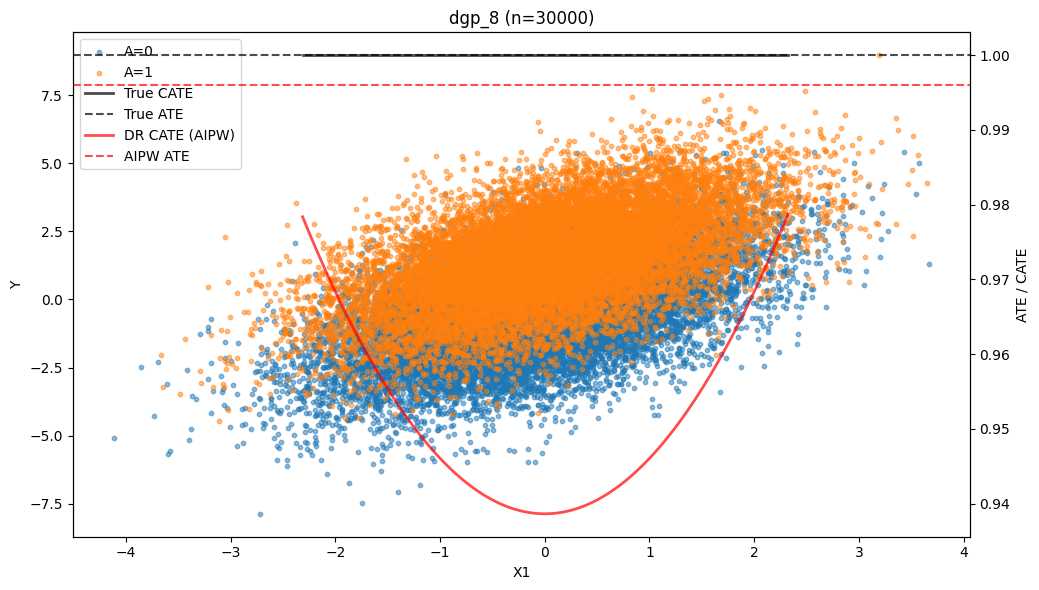

dgp_8 CATE MSE: 0.002440 | ATE MSE: 0.000016


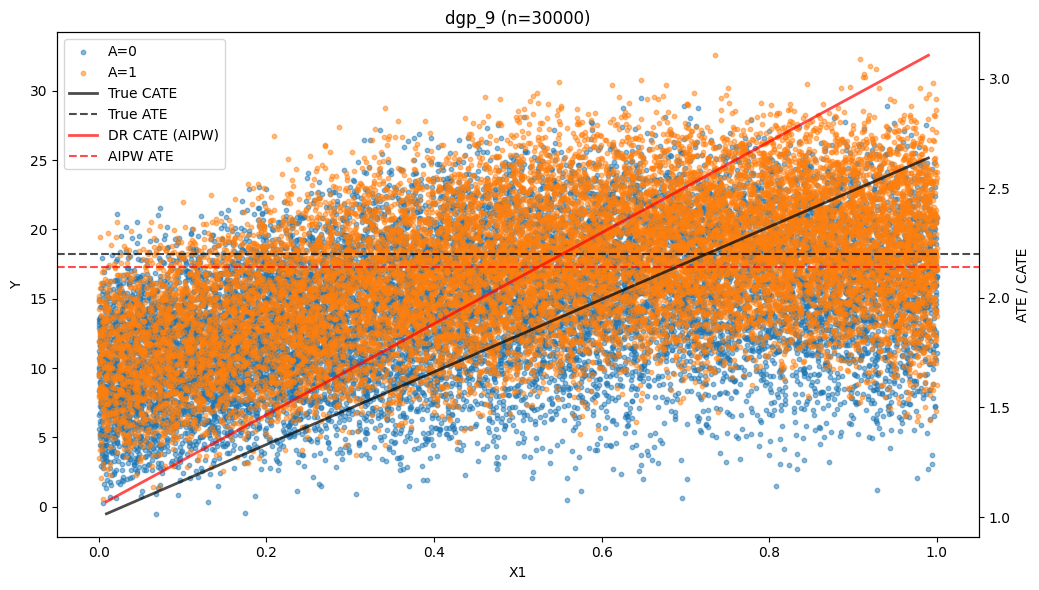

dgp_9 CATE MSE: 0.082982 | ATE MSE: 0.003629


In [4]:
dgps = sorted([k for k in _DGP_REGISTRY.keys() if k != 'dgp_0'], key=dgp_sort_key)

for name in dgps:
    dgp_fn = _DGP_REGISTRY[name]
    data = dgp_fn(N, seed=SEED)
    x = data['X']
    a = data['A']
    y = data['Y']
    ate_true = data.get('ate_true', None)
    cate_true = data.get('cate_true', None)

    x1 = x[:, 0]

    phi_out = compute_phi_and_nuisances(
        x,
        a,
        y,
        phi_fn=compute_phi_aipw,
        n_splits=PHI_N_SPLITS,
        seed=SEED,
        nuisance_fn=fit_nuisance_models,
        nuisance_params={},
        device=DEVICE,
        verbose=False,
        return_models=False,
    )
    phi = phi_out['phi']
    ate_hat = float(phi.mean().detach().cpu().numpy())

    Phi_1d = np.column_stack([np.ones_like(x1), x1, x1 ** 2])
    dr_model = Lasso(alpha=DR_ALPHA, fit_intercept=False, max_iter=10000)
    dr_model.fit(Phi_1d, phi.detach().cpu().numpy())


    fig, ax = plt.subplots(figsize=(10.5, 6))
    ax.scatter(x1[a == 0], y[a == 0], s=10, alpha=0.5, label='A=0')
    ax.scatter(x1[a == 1], y[a == 1], s=10, alpha=0.5, label='A=1')
    ax.set_xlabel('X1')
    ax.set_ylabel('Y')

    ax2 = ax.twinx()
    xg = make_grid_x(x, N_GRID)
    Phi_1d_g = np.column_stack([np.ones_like(xg[:, 0]), xg[:, 0], xg[:, 0] ** 2])
    cate_hat = dr_model.predict(Phi_1d_g)
    cate_mse = None
    if callable(cate_true):
        cate_vals = cate_true(xg)
        ax2.plot(xg[:, 0], cate_vals, 'k-', lw=2, alpha=0.7, label='True CATE')
    if ate_true is not None:
        ax2.axhline(ate_true, color='k', ls='--', lw=1.5, alpha=0.7, label='True ATE')

    ax2.plot(xg[:, 0], cate_hat, color='red', lw=2, alpha=0.7, label='DR CATE (AIPW)')
    ax2.axhline(ate_hat, color='red', ls='--', lw=1.5, alpha=0.7, label='AIPW ATE')
    ax2.set_ylabel('ATE / CATE')

    if callable(cate_true):
        cate_mse = float(np.mean((cate_hat - cate_vals) ** 2))
    ate_mse = None
    if ate_true is not None:
        ate_mse = float((ate_hat - ate_true) ** 2)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc='best')

    ax.set_title(f'{name} (n={N})')
    plt.tight_layout()
    plt.show()

    cate_mse_str = f'{cate_mse:.6f}' if cate_mse is not None else 'NA'
    ate_mse_str = f'{ate_mse:.6f}' if ate_mse is not None else 'NA'
    print(f'{name} CATE MSE: {cate_mse_str} | ATE MSE: {ate_mse_str}')


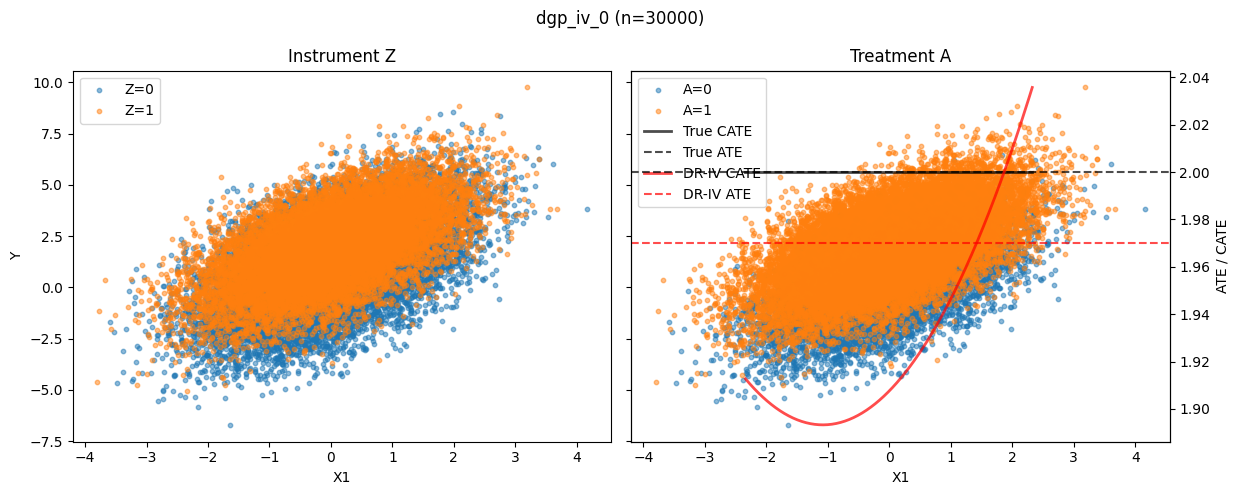

dgp_iv_0 CATE MSE: 0.006591 | ATE MSE: 0.000895


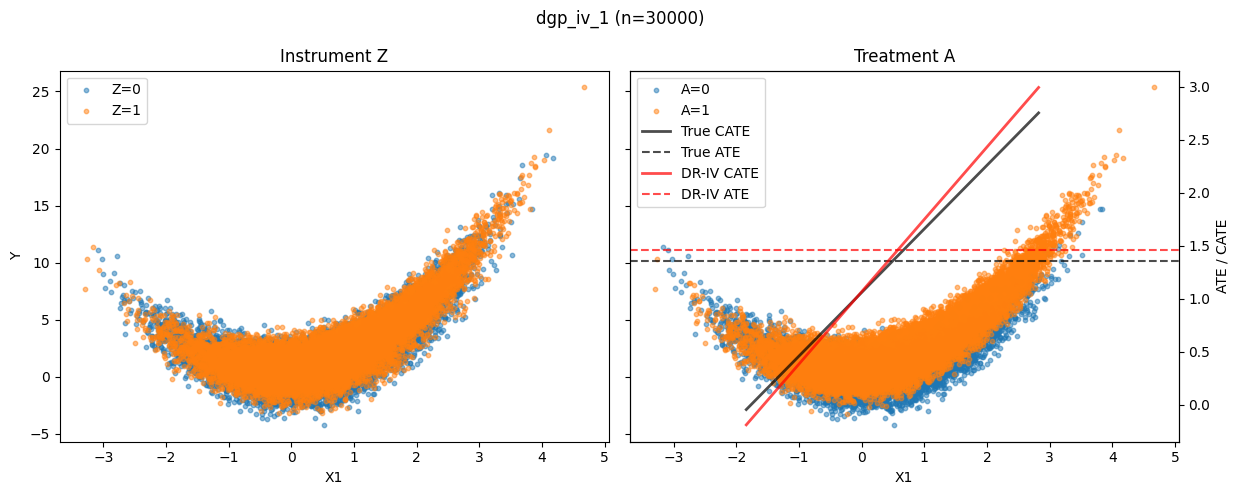

dgp_iv_1 CATE MSE: 0.014697 | ATE MSE: 0.010260


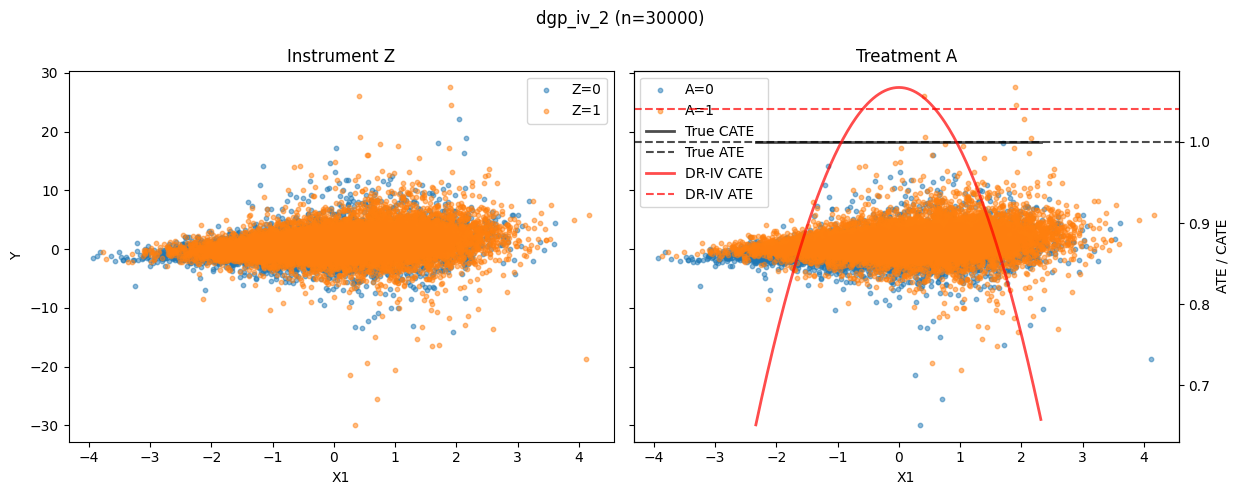

dgp_iv_2 CATE MSE: 0.020598 | ATE MSE: 0.001693


In [5]:
from src import _DGP_IV_REGISTRY, fit_nuisance_models_iv, compute_phi_dr_iv, compute_phi_and_nuisances_iv

def dgp_iv_sort_key(name: str) -> int:
    try:
        return int(name.split('_')[-1])
    except Exception:
        return 0

iv_dgps = sorted(_DGP_IV_REGISTRY.keys(), key=dgp_iv_sort_key)

for name in iv_dgps:
    dgp_fn = _DGP_IV_REGISTRY[name]
    data = dgp_fn(N, seed=SEED)
    x = data['X']
    z = data['Z']
    a = data['A']
    y = data['Y']
    ate_true = data.get('ate_true', None)
    cate_true = data.get('cate_true', None)

    x1 = x[:, 0]

    phi_out = compute_phi_and_nuisances_iv(
        x,
        z,
        a,
        y,
        phi_fn=compute_phi_dr_iv,
        n_splits=PHI_N_SPLITS,
        seed=SEED,
        nuisance_fn=fit_nuisance_models_iv,
        nuisance_params={},
        device=DEVICE,
        verbose=False,
        return_models=False,
    )
    phi = phi_out['phi']
    ate_hat = float(phi.mean().detach().cpu().numpy())

    Phi_1d = np.column_stack([np.ones_like(x1), x1, x1 ** 2])
    dr_model = Lasso(alpha=DR_ALPHA, fit_intercept=False, max_iter=10000)
    dr_model.fit(Phi_1d, phi.detach().cpu().numpy())

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
    axes[0].scatter(x1[z == 0], y[z == 0], s=10, alpha=0.5, label='Z=0')
    axes[0].scatter(x1[z == 1], y[z == 1], s=10, alpha=0.5, label='Z=1')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('Y')
    axes[0].set_title('Instrument Z')

    axes[1].scatter(x1[a == 0], y[a == 0], s=10, alpha=0.5, label='A=0')
    axes[1].scatter(x1[a == 1], y[a == 1], s=10, alpha=0.5, label='A=1')
    axes[1].set_xlabel('X1')
    axes[1].set_title('Treatment A')

    ax2 = axes[1].twinx()
    xg = make_grid_x(x, N_GRID)
    Phi_1d_g = np.column_stack([np.ones_like(xg[:, 0]), xg[:, 0], xg[:, 0] ** 2])
    cate_hat = dr_model.predict(Phi_1d_g)
    cate_mse = None
    if callable(cate_true):
        cate_vals = cate_true(xg)
        ax2.plot(xg[:, 0], cate_vals, 'k-', lw=2, alpha=0.7, label='True CATE')
    if ate_true is not None:
        ax2.axhline(ate_true, color='k', ls='--', lw=1.5, alpha=0.7, label='True ATE')

    ax2.plot(xg[:, 0], cate_hat, color='red', lw=2, alpha=0.7, label='DR-IV CATE')
    ax2.axhline(ate_hat, color='red', ls='--', lw=1.5, alpha=0.7, label='DR-IV ATE')
    ax2.set_ylabel('ATE / CATE')

    if callable(cate_true):
        cate_mse = float(np.mean((cate_hat - cate_vals) ** 2))
    ate_mse = None
    if ate_true is not None:
        ate_mse = float((ate_hat - ate_true) ** 2)

    handles0, labels0 = axes[0].get_legend_handles_labels()
    axes[0].legend(handles0, labels0, loc='best')
    handles1, labels1 = axes[1].get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(handles1 + handles2, labels1 + labels2, loc='best')

    fig.suptitle(f'{name} (n={N})')
    plt.tight_layout()
    plt.show()

    cate_mse_str = f'{cate_mse:.6f}' if cate_mse is not None else 'NA'
    ate_mse_str = f'{ate_mse:.6f}' if ate_mse is not None else 'NA'
    print(f'{name} CATE MSE: {cate_mse_str} | ATE MSE: {ate_mse_str}')


In [6]:
# IV instrument strength diagnostics
import numpy as np
import matplotlib.pyplot as plt
from src import _DGP_IV_REGISTRY

SEED = 123
N = 30000

def iv_strength_summary(data):
    X = data['X']
    Z = data['Z']
    A = data['A']
    p_z1 = np.mean(Z == 1)
    p_a1_z1 = np.mean(A[Z == 1]) if np.any(Z == 1) else np.nan
    p_a1_z0 = np.mean(A[Z == 0]) if np.any(Z == 0) else np.nan
    first_stage = p_a1_z1 - p_a1_z0
    return p_z1, p_a1_z1, p_a1_z0, first_stage

def first_stage_by_x1_bins(data, n_bins=6):
    X = data['X']
    Z = data['Z']
    A = data['A']
    x1 = X[:, 0]
    bins = np.quantile(x1, np.linspace(0, 1, n_bins))
    results = []
    for i in range(len(bins) - 1):
        mask = (x1 >= bins[i]) & (x1 <= bins[i + 1])
        if mask.sum() == 0:
            continue
        p_z1 = np.mean(Z[mask])
        p_a1_z1 = np.mean(A[mask & (Z == 1)]) if np.any(mask & (Z == 1)) else np.nan
        p_a1_z0 = np.mean(A[mask & (Z == 0)]) if np.any(mask & (Z == 0)) else np.nan
        results.append((i, p_z1, p_a1_z1, p_a1_z0))
    return results

for name, dgp_fn in _DGP_IV_REGISTRY.items():
    data = dgp_fn(N, seed=SEED)
    p_z1, p_a1_z1, p_a1_z0, first_stage = iv_strength_summary(data)
    print(f'[{name}] P(Z=1)={p_z1:.3f}, P(A=1|Z=1)={p_a1_z1:.3f}, P(A=1|Z=0)={p_a1_z0:.3f}, first-stage={first_stage:.3f}')
    bins = first_stage_by_x1_bins(data)
    for i, pz, pa1z1, pa1z0 in bins:
        print(f'  bin {i}: P(Z=1)={pz:.3f}, P(A=1|Z=1)={pa1z1:.3f}, P(A=1|Z=0)={pa1z0:.3f}')
    print('')


[dgp_iv_0] P(Z=1)=0.498, P(A=1|Z=1)=0.983, P(A=1|Z=0)=0.503, first-stage=0.480
  bin 0: P(Z=1)=0.502, P(A=1|Z=1)=0.982, P(A=1|Z=0)=0.466
  bin 1: P(Z=1)=0.497, P(A=1|Z=1)=0.984, P(A=1|Z=0)=0.494
  bin 2: P(Z=1)=0.499, P(A=1|Z=1)=0.983, P(A=1|Z=0)=0.500
  bin 3: P(Z=1)=0.504, P(A=1|Z=1)=0.981, P(A=1|Z=0)=0.517
  bin 4: P(Z=1)=0.489, P(A=1|Z=1)=0.985, P(A=1|Z=0)=0.535

[dgp_iv_1] P(Z=1)=0.539, P(A=1|Z=1)=0.874, P(A=1|Z=0)=0.476, first-stage=0.398
  bin 0: P(Z=1)=0.471, P(A=1|Z=1)=0.797, P(A=1|Z=0)=0.355
  bin 1: P(Z=1)=0.510, P(A=1|Z=1)=0.851, P(A=1|Z=0)=0.449
  bin 2: P(Z=1)=0.538, P(A=1|Z=1)=0.882, P(A=1|Z=0)=0.479
  bin 3: P(Z=1)=0.556, P(A=1|Z=1)=0.896, P(A=1|Z=0)=0.521
  bin 4: P(Z=1)=0.618, P(A=1|Z=1)=0.926, P(A=1|Z=0)=0.622

[dgp_iv_2] P(Z=1)=0.573, P(A=1|Z=1)=0.730, P(A=1|Z=0)=0.437, first-stage=0.293
  bin 0: P(Z=1)=0.463, P(A=1|Z=1)=0.663, P(A=1|Z=0)=0.372
  bin 1: P(Z=1)=0.541, P(A=1|Z=1)=0.696, P(A=1|Z=0)=0.407
  bin 2: P(Z=1)=0.573, P(A=1|Z=1)=0.716, P(A=1|Z=0)=0.444
  bin 3